# otherHRD pairwise statistics

Pairwise Mann-Whitney U tests (Benjamini-Hochberg corrected within each metric) of HRD duration and HRDTime across HRD-origin groups (germline, somatic, methylation, otherHRD), plus the 3-panel origin figure. Data from Table S2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations

EXCEL_PATH = "../supplemental_tables_v2/SupTable8_HRDTimer_estimates.xlsx"
S2_INV = {"sample_id": "sample", "subtype": "type", "is_WGD": "isWGD", "tumour_grade": "grade", "clinical_stage": "final_stage_main", "hrd_origin": "hrd.origin", "hrd_origin_with_methylation": "hrd.origin.with.meth", "HRD_genotype": "genotype", "CHORD_genotype": "chord.genotype", "TP53_mutated": "isTp53Mut", "PALB2_mutated": "isPALB2Mut", "HRDetect_score": "HRDetect", "is_HRD": "HRDetect.isHRD", "T_stage": "T_STAGE", "tumour_size_mm": "tum.size.mm", "age_band_label": "age_band", "BRCA1_monoallelic": "isBRCA1Monoallelic", "BRCA1_biallelic": "isBRCA1Biallelic", "BRCA2_monoallelic": "isBRCA2Monoallelic", "BRCA2_biallelic": "isBRCA2Biallelic", "BRCA1_promoter_methylation_class": "BRCA1_PromMetClass", "RAD51C_promoter_methylation_class": "RAD51C_PromMetClass", "HRDTime_molecular": "HRDTime", "HRDTime_molecular_ci_lo": "HRDTime_ci_lo", "HRDTime_molecular_ci_hi": "HRDTime_ci_hi", "HRDTime_molecular_IQR_lo": "HRDTime_ci_IQR_lo", "HRDTime_molecular_IQR_hi": "HRDTime_ci_IQR_hi", "WGDTime_molecular": "WGDTime", "WGDTime_molecular_ci_lo": "WGDTime_ci_lo", "WGDTime_molecular_ci_hi": "WGDTime_ci_hi", "WGDTime_molecular_IQR_lo": "WGDTime_ci_IQR_lo", "WGDTime_molecular_IQR_hi": "WGDTime_ci_IQR_hi", "HRD_duration_median_yrs": "HRD_Duration_median", "HRD_duration_ci05_yrs": "HRD_Duration_ci05", "HRD_duration_ci95_yrs": "HRD_Duration_ci95", "TS_duration_median_yrs": "TS_Duration_median", "TS_duration_ci05_yrs": "TS_Duration_ci05", "TS_duration_ci95_yrs": "TS_Duration_ci95", "HRD_onset_age_median": "HRD_crossing_age_median", "HRD_onset_age_ci05": "HRD_crossing_age_ci05", "HRD_onset_age_ci95": "HRD_crossing_age_ci95", "TS_onset_age_median": "TS_crossing_age_median", "TS_onset_age_ci05": "TS_crossing_age_ci05", "TS_onset_age_ci95": "TS_crossing_age_ci95"}
ORIGIN_ORDER  = ['germline', 'somatic', 'meth', 'otherHRD']

results_df = pd.read_excel(EXCEL_PATH, sheet_name='HRDTimer Estimates').rename(columns=S2_INV)
results_df = results_df[results_df['scaled_SBS1'].notna()].reset_index(drop=True)   # SBS1-timing cohort (matches v3)
print(f"Loaded {len(results_df)} samples")
print(results_df['hrd.origin.with.meth'].value_counts(dropna=False))


# ── GEL: reconstruct age at diagnosis downstream (NOT stored in Table S2) ──
# GEL's approved export discloses only 5-year age bands, so exact age at diagnosis
# is omitted from Table S2. Reconstruct the band midpoint here for the age-by-origin
# panel. (Onset/crossing age is not computed here — only Fig5 panel A uses it.)
import re as _re
def _band_mid(b):
    m = _re.findall(r"\d+", str(b))
    return (int(m[0]) + int(m[1])) / 2 if len(m) >= 2 else np.nan
_gel = results_df["cohort"].eq("GEL")
results_df.loc[_gel, "age_at_diagnosis"] = results_df.loc[_gel, "age_band"].map(_band_mid)


Loaded 115 samples
hrd.origin.with.meth
NaN         35
germline    32
meth        21
somatic     15
otherHRD    12
Name: count, dtype: int64


In [2]:
def rank_biserial(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)

def run_pairwise_bh(data, group_col, val_col, order):
    """All pairwise Mann-Whitney U with BH correction. Returns a DataFrame."""
    pairs = list(combinations(order, 2))
    rows  = []
    for g1, g2 in pairs:
        x1 = data[data[group_col] == g1][val_col].dropna().values
        x2 = data[data[group_col] == g2][val_col].dropna().values
        if len(x1) > 1 and len(x2) > 1:
            u, p = mannwhitneyu(x1, x2, alternative='two-sided')
            r    = rank_biserial(u, len(x1), len(x2))
            rows.append({'group1':g1,'group2':g2,'n1':len(x1),'n2':len(x2),'raw_p':p,'r':r})
        else:
            rows.append({'group1':g1,'group2':g2,'n1':len(x1),'n2':len(x2),'raw_p':np.nan,'r':np.nan})
    out = pd.DataFrame(rows)
    valid = ~out['raw_p'].isna()
    bh_p  = np.full(len(out), np.nan)
    if valid.sum() > 0:
        _, corr, _, _ = multipletests(out.loc[valid, 'raw_p'], method='fdr_bh')
        bh_p[valid.values] = corr
    out['bh_p'] = bh_p
    out['sig']  = out['bh_p'].apply(
        lambda p: '' if np.isnan(p) else '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    )
    return out

def group_summary(data, group_col, val_col, order):
    return (
        data.groupby(group_col)[val_col]
        .agg(n='count',
             median='median',
             q25=lambda x: x.quantile(0.25),
             q75=lambda x: x.quantile(0.75))
        .reindex(order)
    )


In [3]:
dur_df = (
    results_df.dropna(subset=['hrd.origin.with.meth', 'HRD_Duration_median'])
    .pipe(lambda d: d[d['hrd.origin.with.meth'].isin(ORIGIN_ORDER)])
)
hrdtime_df = (
    results_df.dropna(subset=['hrd.origin.with.meth', 'HRDTime'])
    .pipe(lambda d: d[d['hrd.origin.with.meth'].isin(ORIGIN_ORDER)])
)

order = [o for o in ORIGIN_ORDER if o in dur_df['hrd.origin.with.meth'].unique()]

dur_stats     = run_pairwise_bh(dur_df,     'hrd.origin.with.meth', 'HRD_Duration_median', order)
hrdtime_stats = run_pairwise_bh(hrdtime_df, 'hrd.origin.with.meth', 'HRDTime',             order)

print("Group sizes:", dur_df['hrd.origin.with.meth'].value_counts().to_dict())


Group sizes: {'germline': 28, 'meth': 21, 'somatic': 12, 'otherHRD': 12}


## Full pairwise tables

In [4]:
pd.set_option('display.float_format', '{:.3e}'.format)
print("HRD Duration:")
print(dur_stats[['group1','group2','n1','n2','raw_p','bh_p','sig']].to_string(index=False))
print()
print("HRDTime:")
print(hrdtime_stats[['group1','group2','n1','n2','raw_p','bh_p','sig']].to_string(index=False))


HRD Duration:
  group1   group2  n1  n2     raw_p      bh_p sig
germline  somatic  28  12 5.649e-01 6.779e-01  ns
germline     meth  28  21 7.086e-01 7.086e-01  ns
germline otherHRD  28  12 3.015e-03 6.031e-03  **
 somatic     meth  12  21 4.210e-01 6.316e-01  ns
 somatic otherHRD  12  12 2.437e-03 6.031e-03  **
    meth otherHRD  21  12 1.207e-03 6.031e-03  **

HRDTime:
  group1   group2  n1  n2     raw_p      bh_p sig
germline  somatic  32  15 8.284e-01 9.637e-01  ns
germline     meth  32  21 9.637e-01 9.637e-01  ns
germline otherHRD  32  12 5.839e-04 1.752e-03  **
 somatic     meth  15  21 8.725e-01 9.637e-01  ns
 somatic otherHRD  15  12 3.692e-03 7.385e-03  **
    meth otherHRD  21  12 1.963e-04 1.178e-03  **


## Manuscript-ready: otherHRD vs each group

In [5]:
dur_medians     = group_summary(dur_df,     'hrd.origin.with.meth', 'HRD_Duration_median', order)
hrdtime_medians = group_summary(hrdtime_df,  'hrd.origin.with.meth', 'HRDTime',             order)

def otherhrd_summary(stats_df, medians_df, val_label):
    mask = (stats_df['group1'] == 'otherHRD') | (stats_df['group2'] == 'otherHRD')
    sub  = stats_df[mask].copy()
    flip = sub['group1'] == 'otherHRD'
    sub.loc[flip, ['group1','group2']] = sub.loc[flip, ['group2','group1']].values
    sub = sub.reset_index(drop=True)

    print(f"{'='*72}")
    print(f"{val_label}  —  otherHRD comparisons (Mann-Whitney U, BH-corrected)")
    print(f"{'='*72}")
    other_med = medians_df.loc['otherHRD']
    print(f"  otherHRD:  median={other_med['median']:.1f}  IQR [{other_med['q25']:.1f}–{other_med['q75']:.1f}]  (n={int(other_med['n'])})")
    print()
    for _, row in sub.iterrows():
        g  = row['group1']
        m  = medians_df.loc[g]
        print(f"  vs {g:<10}  median={m['median']:.1f}  IQR [{m['q25']:.1f}–{m['q75']:.1f}]  (n={int(m['n'])})  "
              f"BH p={row['bh_p']:.3e}  {row['sig']}")

otherhrd_summary(dur_stats,     dur_medians,     'HRD Duration (years)')
print()
otherhrd_summary(hrdtime_stats, hrdtime_medians, 'HRDTime')


HRD Duration (years)  —  otherHRD comparisons (Mann-Whitney U, BH-corrected)
  otherHRD:  median=6.5  IQR [5.7–7.9]  (n=12)

  vs germline    median=11.0  IQR [7.9–19.6]  (n=28)  BH p=6.031e-03  **
  vs somatic     median=15.0  IQR [7.7–22.9]  (n=12)  BH p=6.031e-03  **
  vs meth        median=9.7  IQR [8.3–12.7]  (n=21)  BH p=6.031e-03  **

HRDTime  —  otherHRD comparisons (Mann-Whitney U, BH-corrected)
  otherHRD:  median=0.5  IQR [0.4–0.6]  (n=12)

  vs germline    median=0.3  IQR [0.2–0.4]  (n=32)  BH p=1.752e-03  **
  vs somatic     median=0.3  IQR [0.1–0.4]  (n=15)  BH p=7.385e-03  **
  vs meth        median=0.3  IQR [0.2–0.4]  (n=21)  BH p=1.178e-03  **


## Reproduce the 3-panel origin figure

> **GEL note:** GEL's exact age at diagnosis is not disclosed; for the age-by-origin panel we use the **5-year age-band midpoint** (reconstructed downstream, not stored in Table S2).

/tmp/ipykernel_473486/3528399102.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dur_plot_df, x='hrd.origin.with.meth', y='HRD_Duration',
/tmp/ipykernel_473486/3528399102.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hrdtime_plot_df, x='hrd.origin.with.meth', y='HRDTime',
/tmp/ipykernel_473486/3528399102.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


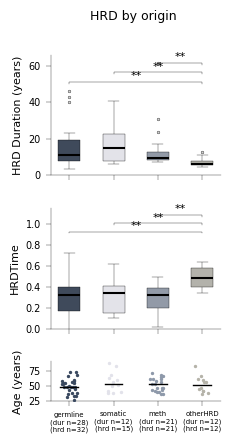

In [6]:
# ── Style ────────────────────────────────────────────────────────────────────
def set_mpl_style():
    mpl.rcParams.update({
        'pdf.fonttype': 42, 'ps.fonttype': 42,
        'font.family': 'sans-serif', 'font.size': 13,
        'axes.spines.top': False, 'axes.spines.right': False,
        'axes.linewidth': 0.5, 'xtick.direction': 'out', 'ytick.direction': 'out',
        'xtick.major.width': 0.5, 'ytick.major.width': 0.5,
        'xtick.labelsize': 10, 'ytick.labelsize': 10,
    })
set_mpl_style()

# ── Constants ────────────────────────────────────────────────────────────────
BOX_PROPS = dict(
    boxprops     = dict(edgecolor='black', linewidth=0.25),
    whiskerprops = dict(color='black', linewidth=0.25),
    capprops     = dict(color='black', linewidth=0.25),
    medianprops  = dict(color='black', linewidth=1.5),
    flierprops   = dict(marker='o', markersize=2, markerfacecolor='lightgrey',
                        markeredgecolor='k', markeredgewidth=0.25),
)
SPINE_LW     = 0.25
PALETTE      = {'somatic': '#e2e2ea', 'meth': '#8e99aa',
                'germline': '#3a4960', 'otherHRD': '#b5b3a9'}
KEEP_ORIGINS = ORIGIN_ORDER

stars_fn = lambda p: '' if np.isnan(p) else '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'

def bh_test_plot(df, group_col, val_col, order):
    """Returns (pairs, corr_p) — signature matching the plot's sig_brackets call."""
    pairs  = list(combinations(order, 2))
    raw_p  = [mannwhitneyu(df[df[group_col]==g1][val_col],
                           df[df[group_col]==g2][val_col], alternative='two-sided')[1]
              if (df[group_col]==g1).sum() > 1 and (df[group_col]==g2).sum() > 1
              else np.nan for g1, g2 in pairs]
    corr_p = {i: np.nan for i in range(len(pairs))}
    valid  = [(i, p) for i, p in enumerate(raw_p) if not np.isnan(p)]
    if valid:
        idxs, pvals = zip(*valid)
        _, corr, _, _ = multipletests(pvals, method='fdr_bh')
        corr_p.update(zip(idxs, corr))
    return pairs, corr_p

def sig_brackets(ax, pairs, corr_p, order, y_lim, y_step):
    sig = [(pairs[i], stars_fn(corr_p[i])) for i in range(len(pairs))
           if stars_fn(corr_p[i]) not in ('', 'ns')]
    for level, (pair, star) in enumerate(sig):
        if pair[0] not in order or pair[1] not in order: continue
        x1, x2 = order.index(pair[0]), order.index(pair[1])
        y = y_lim - y_step * (len(sig) - level)
        ax.plot([x1, x1, x2, x2], [y, y+y_step*0.2, y+y_step*0.2, y],
                lw=0.25, color='black', clip_on=False)
        ax.text((x1+x2)/2, y+y_step*0.25, star,
                ha='center', va='bottom', fontsize=8, clip_on=False)

def style_ax(ax, ylabel):
    ax.set(xlabel='', ylabel=ylabel)
    ax.yaxis.label.set_fontsize(8)
    for key, sp in ax.spines.items():
        sp.set_visible(key in ('left', 'bottom'))
        sp.set_linewidth(SPINE_LW)
    ax.tick_params(width=SPINE_LW, labelsize=7)

# ── Build data frames from iter CSV + Excel ───────────────────────────────────
origin_map = (
    results_df[['sample', 'hrd.origin.with.meth']]
    .dropna(subset=['hrd.origin.with.meth'])
    .drop_duplicates('sample')
)

dur_plot_df = (
    results_df[['sample', 'hrd.origin.with.meth', 'HRD_Duration_median']]
    .rename(columns={'HRD_Duration_median': 'HRD_Duration'})
    .drop_duplicates('sample').dropna(subset=['hrd.origin.with.meth', 'HRD_Duration'])
    .pipe(lambda d: d[d['hrd.origin.with.meth'].isin(KEEP_ORIGINS)])
)

hrdtime_plot_df = (
    results_df[['sample', 'hrd.origin.with.meth', 'HRDTime']]
    .drop_duplicates('sample').dropna(subset=['HRDTime'])
    .pipe(lambda d: d[d['hrd.origin.with.meth'].isin(KEEP_ORIGINS)])
)

age_plot_df = (
    results_df[['sample', 'hrd.origin.with.meth', 'age_at_diagnosis']]
    .rename(columns={'age_at_diagnosis': 'age'})
    .drop_duplicates('sample')
    .dropna(subset=['hrd.origin.with.meth', 'age'])
    .pipe(lambda d: d[d['sample'].isin(dur_plot_df['sample'].unique()) &
                      d['hrd.origin.with.meth'].isin(KEEP_ORIGINS)])
)

origin_order = [o for o in ORIGIN_ORDER if o in dur_plot_df['hrd.origin.with.meth'].unique()]

# ── Stats for brackets ────────────────────────────────────────────────────────
dur_pairs,     dur_corr     = bh_test_plot(dur_plot_df,     'hrd.origin.with.meth', 'HRD_Duration', origin_order)
hrdtime_pairs, hrdtime_corr = bh_test_plot(hrdtime_plot_df, 'hrd.origin.with.meth', 'HRDTime',      origin_order)
# NOTE: age is shown as a dot plot only (visualization). No p-values are computed for age
# — statistics are reported for HRD duration (and HRDTime). For GEL, 'age' here is the
# 5-year age-band midpoint (see load cell); exact GEL age is not disclosed.

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(2.2, 4.5))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 3, 1], hspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

sns.boxplot(data=dur_plot_df, x='hrd.origin.with.meth', y='HRD_Duration',
            order=origin_order, palette=PALETTE, width=0.5, ax=ax1, **BOX_PROPS)
sig_brackets(ax1, dur_pairs, dur_corr, origin_order, y_lim=66, y_step=66*0.08)
ax1.set_ylim(0, 66); style_ax(ax1, 'HRD Duration (years)')
ax1.tick_params(labelbottom=False)

sns.boxplot(data=hrdtime_plot_df, x='hrd.origin.with.meth', y='HRDTime',
            order=origin_order, palette=PALETTE, width=0.5, ax=ax2, **BOX_PROPS)
sig_brackets(ax2, hrdtime_pairs, hrdtime_corr, origin_order, y_lim=1.15, y_step=0.08)
ax2.set_ylim(0, 1.15); style_ax(ax2, 'HRDTime')
ax2.tick_params(labelbottom=False)

rng = np.random.default_rng(42)
for xi, origin in enumerate(origin_order):
    ages = age_plot_df[age_plot_df['hrd.origin.with.meth'] == origin]['age'].values
    if len(ages) == 0: continue
    ax3.scatter(xi + rng.uniform(-0.18, 0.18, len(ages)), ages,
                color=PALETTE.get(origin, '#888888'), s=2, zorder=3, alpha=1)
    ax3.plot([xi-0.2, xi+0.2], [np.median(ages)]*2,
             color='black', linewidth=1, zorder=4)

style_ax(ax3, 'Age (years)')
ax3.set_xticks(range(len(origin_order)))
ax3.set_xticklabels(
    [f"{o}\n(dur n={len(dur_plot_df[dur_plot_df['hrd.origin.with.meth']==o])})"
     f"\n(hrd n={len(hrdtime_plot_df[hrdtime_plot_df['hrd.origin.with.meth']==o])})"
     for o in origin_order], fontsize=5)

plt.suptitle('HRD by origin', fontsize=9, y=.98)
plt.tight_layout()
plt.show()
